<a href="https://colab.research.google.com/github/DikozWorld/Phishing_Project_EDA/blob/main/Phishing_Project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Инициализация и загрузка (Data Loading).**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path = '/content/drive/MyDrive/Phishing_Project/email_phishing_data.csv'

# Загружаем датасет в переменную df
df = pd.read_csv(file_path)

# Выводим первые 5 строк таблицы, чтобы убедиться, что всё загрузилось успешно
df.head()

Mounted at /content/drive


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


**Первичный осмотр данных (Data Profiling)**

In [ ]:
# 1. Узнаем точное количество строк и столбцов (размерность матрицы)
print("Размер датасета:", df.shape)

# 2. Посмотрим общую техническую информацию (типы данных в колонках и наличие пустых значений)
df.info()

# 3. Самое важное для нас: посмотрим баланс классов (целевой переменной)
# Сколько нормальных писем (0) и сколько фишинговых (1)
# Смотрим баланс классов по колонке 'label'
print("\nБаланс классов:")
print(df['label'].value_counts())

Размер датасета: (524846, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524846 entries, 0 to 524845
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   num_words            524846 non-null  int64
 1   num_unique_words     524846 non-null  int64
 2   num_stopwords        524846 non-null  int64
 3   num_links            524846 non-null  int64
 4   num_unique_domains   524846 non-null  int64
 5   num_email_addresses  524846 non-null  int64
 6   num_spelling_errors  524846 non-null  int64
 7   num_urgent_keywords  524846 non-null  int64
 8   label                524846 non-null  int64
dtypes: int64(9)
memory usage: 36.0 MB

Баланс классов:
label
0    517897
1      6949
Name: count, dtype: int64


**Проверка на нули**

In [ ]:
print("Проверка на наличие пропущенных значений (Null/NaN):")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nВердикт: Пропусков нет, заполнение (Imputation) из Темы 10 не требуется.")
else:
    print("\nВердикт: Есть пропуски, требуется обработка.")

Проверка на наличие пропущенных значений (Null/NaN):
Series([], dtype: int64)

Вердикт: Пропусков нет, заполнение (Imputation) из Темы 10 не требуется.


**Визуальный разведочный анализ (Visual EDA).**

/tmp/ipykernel_33678/1584046773.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])


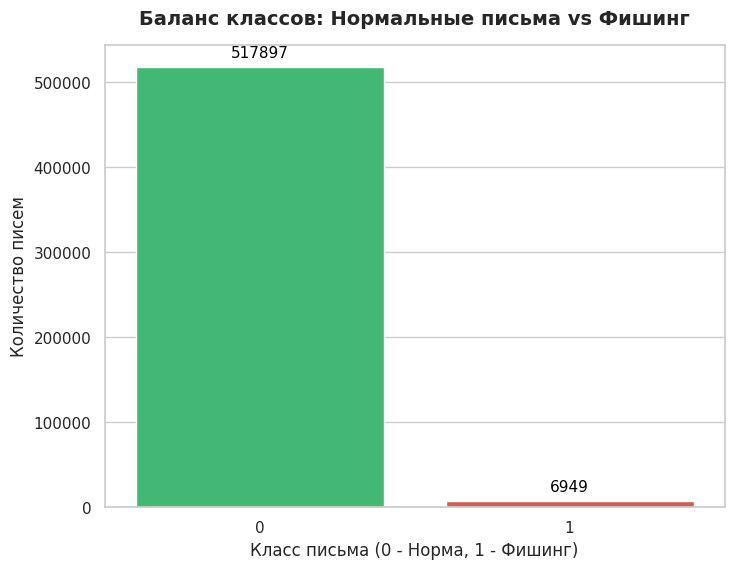

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Настраиваем красивый визуальный стиль графика
sns.set_theme(style="whitegrid")

# 2. Создаем "холст" размером 8 на 6 дюймов
plt.figure(figsize=(8, 6))

# 3. Строим сам график.
# Используем цвета: зеленый (#2ecc71) для хороших писем и красный (#e74c3c) для фишинга
ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])

# 4. Добавляем понятные подписи (это очень важно для презентаций!)
plt.title('Баланс классов: Нормальные письма vs Фишинг', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Класс письма (0 - Норма, 1 - Фишинг)', fontsize=12)
plt.ylabel('Количество писем', fontsize=12)

# 5. Цикл, который пишет точные цифры прямо над столбиками графика
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

# Показываем результат
plt.show()

**Сравнительный анализ признаков**

In [ ]:
# Смотрим среднее количество ссылок в нормальных (0) и фишинговых (1) письмах
df.groupby('label')['num_links'].mean()

,num_links
label,
0,0.901921
1,0.423658


**Статистический анализ (Feature Correlation).**

Найдено полных дубликатов в данных: 319794
Дубликаты удалены. Новый размер датасета: (205052, 9)

Базовая статистика по датасету (первые 5 колонок для компактности):


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains
count,205052.00,205052.00,205052.00,205052.00,205052.00
mean,344.90,147.71,99.12,1.43,0.48
std,5255.02,232.31,1613.04,7.99,2.26
min,0.00,0.00,0.00,0.00,0.00
25%,79.00,57.00,21.00,0.00,0.00
50%,161.00,99.00,46.00,0.00,0.00
75%,327.00,170.00,98.00,0.00,0.00
max,2339682.00,51251.00,720411.00,824.00,524.00


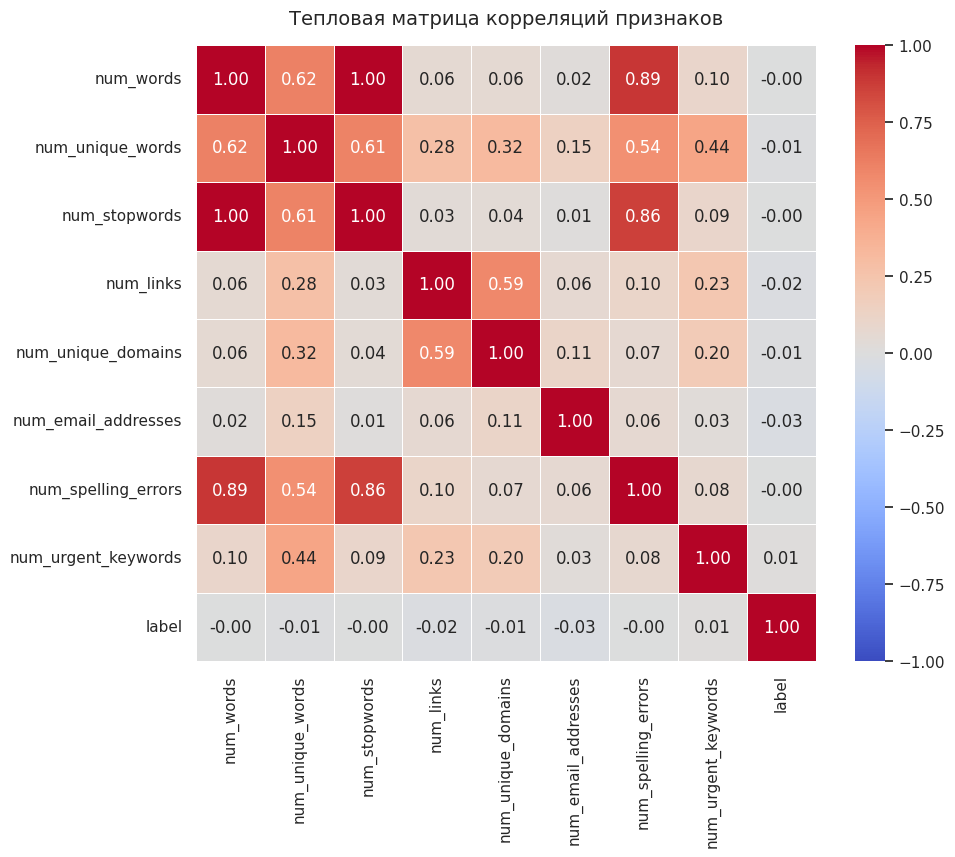

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"Найдено полных дубликатов в данных: {duplicates}")

# Если дубликаты есть, их принято удалять, чтобы они не сбивали модель
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Дубликаты удалены. Новый размер датасета: {df.shape}\n")

# 2. Базовая статистика (выводим с округлением для красоты)
print("Базовая статистика по датасету (первые 5 колонок для компактности):")
display(df.iloc[:, :5].describe().round(2))

# 3. Красивая тепловая карта корреляций
plt.figure(figsize=(10, 8))
# Считаем матрицу корреляций
corr_matrix = df.corr()
# Рисуем график. cmap='coolwarm' дает понятные цвета (красный - сильная связь, синий - обратная)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Тепловая матрица корреляций признаков', fontsize=14, pad=15)
plt.show()

**Расчет корреляции признаков**

In [ ]:
# Считаем корреляцию всех признаков с целевой переменной 'label'
# и сортируем по убыванию, чтобы увидеть самые важные признаки в топе
correlations = df.corr()['label'].sort_values(ascending=False)

print("Влияние признаков на фишинг (корреляция):")
print(correlations)

Влияние признаков на фишинг (корреляция):
label                  1.000000
num_urgent_keywords    0.014733
num_stopwords         -0.002236
num_words             -0.003001
num_spelling_errors   -0.004299
num_unique_words      -0.011579
num_unique_domains    -0.014184
num_links             -0.022402
num_email_addresses   -0.027898
Name: label, dtype: float64


**Разбиение на Train/Test.**

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Отделяем признаки (X) от целевой переменной (y)
X = df.drop(columns=['label']) # Все колонки, кроме ответа
y = df['label']                # Только колонка с ответом

# 2. Разбиваем данные на train и test
# test_size=0.2 означает 20% на тест. random_state=42 — фиксирует случайность, чтобы код всегда выдавал одинаковый результат.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Проверяем, что получилось
print(f"Обучающая выборка (X_train): {X_train.shape}")
print(f"Тестовая выборка (X_test): {X_test.shape}")

Обучающая выборка (X_train): (164041, 8)
Тестовая выборка (X_test): (41011, 8)


**Масштабирование признаков**

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Создаем объект масштабирования
scaler = StandardScaler()

# 2. "Обучаем" масштаб на тренировочных данных и сразу их трансформируем
X_train_scaled = scaler.fit_transform(X_train)

# 3. Тестовые данные ТОЛЬКО трансформируем (используем те же параметры, что нашли на тренировочных)
X_test_scaled = scaler.transform(X_test)

# Превратим обратно в DataFrame для наглядности (чтобы красиво вывести на экран)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Данные успешно масштабированы!")
print("\nПример первых 3 строк масштабированных признаков:")
display(X_train_scaled_df.head(3).round(2))

Данные успешно масштабированы!

Пример первых 3 строк масштабированных признаков:


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords
0,-0.05,-0.39,-0.04,0.69,0.63,-0.17,-0.04,-0.49
1,-0.03,-0.13,-0.02,-0.18,-0.20,-0.10,-0.06,-0.49
2,-0.05,-0.47,-0.04,-0.18,-0.20,-0.17,-0.06,-0.49


**Случайный лес**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Начинаем обучение Случайного леса... (это может занять около 10-30 секунд)")

# 1. Создаем модель.
# Параметр class_weight='balanced' заставит модель штрафовать себя сильнее за пропуск фишинга!
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# 2. Обучаем модель на тренировочных (масштабированных) данных
rf_model.fit(X_train_scaled, y_train)

# 3. Просим модель предсказать ответы для тестовой выборки (экзамен)
y_pred = rf_model.predict(X_test_scaled)

print("\nОбучение завершено! Вот результаты экзамена:\n")

# 4. Выводим главный отчет дата-саентиста
print(classification_report(y_test, y_pred, digits=3))

Начинаем обучение Случайного леса... (это может занять около 10-30 секунд)

Обучение завершено! Вот результаты экзамена:

              precision    recall  f1-score   support

           0      0.974     0.996     0.985     39795
           1      0.513     0.143     0.224      1216

    accuracy                          0.971     41011
   macro avg      0.744     0.569     0.604     41011
weighted avg      0.961     0.971     0.962     41011



In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("1. Применяем магию SMOTE к обучающей выборке (создаем синтетический фишинг)...")
# random_state=42 фиксирует генератор случайностей, чтобы результат всегда был одинаковым
smote = SMOTE(random_state=42)

# Генерируем новые данные. Обрати внимание: мы подаем сюда только Train!
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Размер данных ДО SMOTE: {X_train_scaled.shape}")
print(f"Размер данных ПОСЛЕ SMOTE: {X_train_smote.shape}\n")

print("2. Обучаем НОВЫЙ Случайный Лес на сбалансированных данных...")
# Параметр class_weight='balanced' нам больше не нужен, классы и так равны
rf_smote_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_smote_model.fit(X_train_smote, y_train_smote)

print("3. Сдаем экзамен на СТАРОЙ, нетронутой тестовой выборке...")
y_pred_smote = rf_smote_model.predict(X_test_scaled)

print("\nОбучение завершено! НОВЫЙ ОТЧЕТ (С применением SMOTE):")
print(classification_report(y_test, y_pred_smote, digits=3))

1. Применяем магию SMOTE к обучающей выборке (создаем синтетический фишинг)...
Размер данных ДО SMOTE: (164041, 8)
Размер данных ПОСЛЕ SMOTE: (318352, 8)

2. Обучаем НОВЫЙ Случайный Лес на сбалансированных данных...
3. Сдаем экзамен на СТАРОЙ, нетронутой тестовой выборке...

Обучение завершено! НОВЫЙ ОТЧЕТ (С применением SMOTE):
              precision    recall  f1-score   support

           0      0.978     0.975     0.976     39795
           1      0.262     0.296     0.278      1216

    accuracy                          0.954     41011
   macro avg      0.620     0.635     0.627     41011
weighted avg      0.957     0.954     0.956     41011



**Пробуем линейную регрессию**

In [ ]:
from sklearn.linear_model import LogisticRegression

print("Начинаем обучение Логистической регрессии (Тема 9)...")
# max_iter=1000 нужно, чтобы алгоритм успел "досчитать" математику до конца
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Обучаем на тех же сбалансированных данных, что и Лес
log_reg.fit(X_train_smote, y_train_smote)

# Сдаем экзамен
y_pred_log = log_reg.predict(X_test_scaled)

print("\nОбучение завершено! Отчет Логистической регрессии:")
print(classification_report(y_test, y_pred_log, digits=3))

Начинаем обучение Логистической регрессии (Тема 9)...

Обучение завершено! Отчет Логистической регрессии:
              precision    recall  f1-score   support

           0      0.993     0.393     0.563     39795
           1      0.044     0.913     0.084      1216

    accuracy                          0.408     41011
   macro avg      0.519     0.653     0.323     41011
weighted avg      0.965     0.408     0.549     41011



**Градиентный Бустинг**

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report

print("Начинаем обучение XGBoost (Градиентный бустинг)...")
# Создаем модель.
# n_estimators=200 - количество деревьев в "эстафете"
# max_depth=6 - глубина каждого дерева (чтобы не переобучалось)
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# Обучаем на сбалансированных SMOTE данных!
xgb_model.fit(X_train_smote, y_train_smote)

# Экзамен на тестовой выборке
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("\nОбучение завершено! Отчет XGBoost:")
print(classification_report(y_test, y_pred_xgb, digits=3))

Начинаем обучение XGBoost (Градиентный бустинг)...

Обучение завершено! Отчет XGBoost:
              precision    recall  f1-score   support

           0      0.980     0.952     0.966     39795
           1      0.194     0.375     0.256      1216

    accuracy                          0.935     41011
   macro avg      0.587     0.664     0.611     41011
weighted avg      0.957     0.935     0.945     41011

